## Data Processing

Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Display settings

In [7]:
pd.set_option("display.max.columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", None)

Load dataset

In [8]:
df = pd.read_csv("ai_job_dataset.csv")

Preview

In [9]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


Data shape

In [10]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 15000
Columns: 19


Data Information

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  str    
 1   job_title               15000 non-null  str    
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  str    
 4   experience_level        15000 non-null  str    
 5   employment_type         15000 non-null  str    
 6   company_location        15000 non-null  str    
 7   company_size            15000 non-null  str    
 8   employee_residence      15000 non-null  str    
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  str    
 11  education_required      15000 non-null  str    
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  str    
 14  posting_date            15000 non-null  str    
 

In [12]:
df.columns.tolist()

['job_id',
 'job_title',
 'salary_usd',
 'salary_currency',
 'experience_level',
 'employment_type',
 'company_location',
 'company_size',
 'employee_residence',
 'remote_ratio',
 'required_skills',
 'education_required',
 'years_experience',
 'industry',
 'posting_date',
 'application_deadline',
 'job_description_length',
 'benefits_score',
 'company_name']

In [13]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


## Data Cleaning

Check for duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

Unique categories

In [15]:
df["experience_level"].value_counts()

experience_level
MI    3781
EX    3760
SE    3741
EN    3718
Name: count, dtype: int64

In [16]:
df["employment_type"].value_counts()

employment_type
FT    3812
FL    3758
CT    3721
PT    3709
Name: count, dtype: int64

In [17]:
df["company_size"].value_counts()

company_size
S    5007
L    4998
M    4995
Name: count, dtype: int64

In [18]:
df["remote_ratio"].value_counts().sort_index()

remote_ratio
0      5075
50     5005
100    4920
Name: count, dtype: int64

Date preview

In [19]:
df[["posting_date", "application_deadline"]].head()

,posting_date,application_deadline
0,2024-10-18,2024-11-07
1,2024-11-20,2025-01-11
2,2025-03-18,2025-04-07
3,2024-12-23,2025-02-24
4,2025-04-15,2025-06-23


Convert data columns

In [20]:
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["application_deadline"] = pd.to_datetime(df["application_deadline"])

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  str           
 1   job_title               15000 non-null  str           
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  str           
 4   experience_level        15000 non-null  str           
 5   employment_type         15000 non-null  str           
 6   company_location        15000 non-null  str           
 7   company_size            15000 non-null  str           
 8   employee_residence      15000 non-null  str           
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  str           
 11  education_required      15000 non-null  str           
 12  years_experience        15000 non-null  int64         
 1

In [22]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

Remove unnecessary columns

In [23]:
columns_to_remove = [
    "job_id",
    "salary_currency",
    "employee_residence",
    "job_description_length"
]

df.drop(columns=columns_to_remove, inplace=True)

In [24]:
df.columns

Index(['job_title', 'salary_usd', 'experience_level', 'employment_type', 'company_location', 'company_size', 'remote_ratio', 'required_skills', 'education_required', 'years_experience', 'industry', 'posting_date', 'application_deadline', 'benefits_score', 'company_name'], dtype='str')

Create readable labels

In [25]:
df["experience_level"] = df["experience_level"].replace({
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive Level"
})

In [26]:
df["company_size"] = df["company_size"].replace({
    "S": "Small",
    "M": "Medium",
    "L": "Large"
})

In [27]:
df["employment_type"] = df["employment_type"].replace({
    "FT": "Full-Time",
    "PT": "Part-Time",
    "CT": "Contract",
    "FL": "Freelance"
})

In [28]:
df.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,benefits_score,company_name
0,AI Research Scientist,90376,Senior Level,Contract,China,Medium,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,5.9,Smart Analytics
1,AI Software Engineer,61895,Entry Level,Contract,Canada,Medium,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,5.2,TechCorp Inc
2,AI Specialist,152626,Mid Level,Freelance,Switzerland,Large,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,9.4,Autonomous Tech
3,NLP Engineer,80215,Senior Level,Freelance,India,Medium,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,8.6,Future Systems
4,AI Consultant,54624,Entry Level,Part-Time,France,Small,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,6.6,Advanced Robotics


## Feature Engineering

In [29]:
df["remote_work_type"] = df["remote_ratio"].replace({
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
})

In [30]:
df["posting_year"] = df["posting_date"].dt.year

In [31]:
df["posting_month_num"] = df["posting_date"].dt.month

In [32]:
df["posting_month"] = df["posting_date"].dt.month_name()


In [33]:
df["application_duration"] = (
    df["application_deadline"] - df["posting_date"]
).dt.days

In [34]:
df.head()

,job_title,salary_usd,experience_level,employment_type,company_location,company_size,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,benefits_score,company_name,remote_work_type,posting_year,posting_month_num,posting_month,application_duration
0,AI Research Scientist,90376,Senior Level,Contract,China,Medium,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,5.9,Smart Analytics,Hybrid,2024,10,October,20
1,AI Software Engineer,61895,Entry Level,Contract,Canada,Medium,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,5.2,TechCorp Inc,Remote,2024,11,November,52
2,AI Specialist,152626,Mid Level,Freelance,Switzerland,Large,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,9.4,Autonomous Tech,On-site,2025,3,March,20
3,NLP Engineer,80215,Senior Level,Freelance,India,Medium,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,8.6,Future Systems,Hybrid,2024,12,December,63
4,AI Consultant,54624,Entry Level,Part-Time,France,Small,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,6.6,Advanced Robotics,Remote,2025,4,April,69


## Exploratory Data Analysis (EDA)

### AI Job Market Evolution

#### Question
**How has the AI job market evolved over time?**

In [35]:
job_postings_month = (
    df.groupby(["posting_year", "posting_month_num", "posting_month"])
      .size()
      .reset_index(name="job_postings")
      .sort_values(["posting_year", "posting_month_num"])
)

job_postings_month

,posting_year,posting_month_num,posting_month,job_postings
0,2024,1,January,953
1,2024,2,February,927
2,2024,3,March,932
3,2024,4,April,985
4,2024,5,May,955
5,2024,6,June,938
6,2024,7,July,959
7,2024,8,August,958
8,2024,9,September,895
9,2024,10,October,949


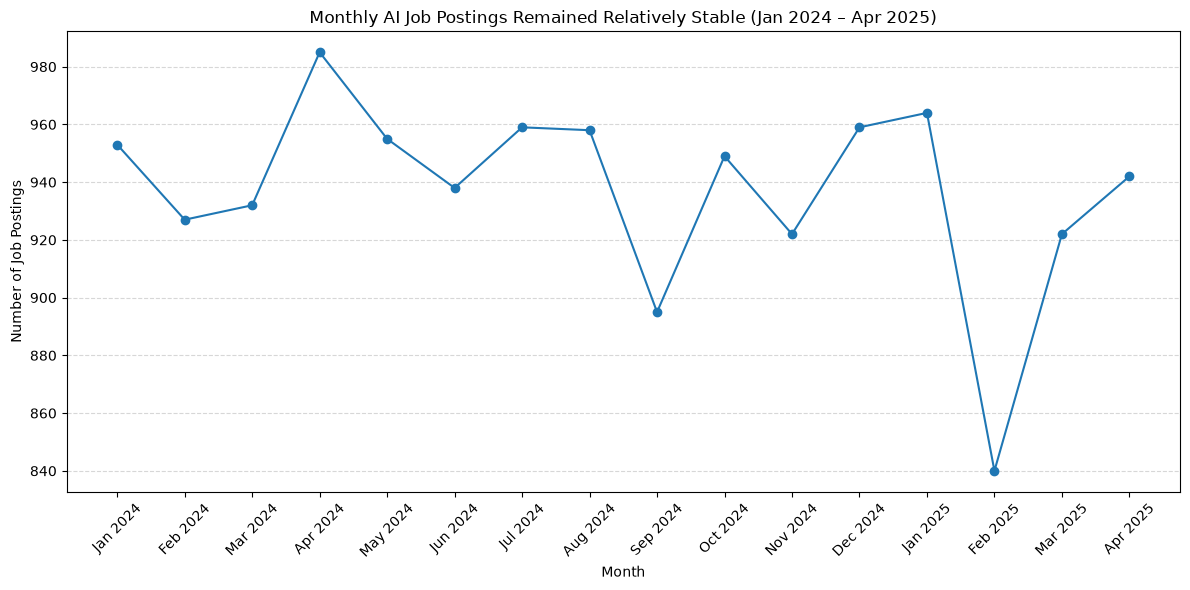

In [ ]:
plt.figure(figsize=(12, 6))
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.plot(
    range(len(job_postings_month)),
    job_postings_month["job_postings"],
    marker="o"
)

labels = (
    job_postings_month["posting_month"].str[:3]
    + " "
    + job_postings_month["posting_year"].astype(str)
)

plt.xticks(range(len(labels)), labels, rotation=45)

plt.title("Monthly AI Job Postings Remained Relatively Stable (Jan 2024 – Apr 2025)")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

##### Key Insights:
- The dataset contains **15,000 AI job postings** spanning **January 2024 to April 2025**.
- Monthly job postings remained relatively stable, ranging from **840 to 985** postings.
- **April 2024** recorded the highest number of job postings (**985**).
- **February 2025** recorded the lowest number of job postings (**840**).
- Overall, the dataset shows **consistent AI hiring activity** throughout the observed period, with no significant upward or downward trend.

### Emerging Job Roles & Skills

#### Question
**Which AI job roles are most frequently advertised?**

In [37]:
top_job_roles = (
    df["job_title"]
    .value_counts()
    .reset_index()
)

top_job_roles.columns = ["job_title", "job_postings"]

top_job_roles.head(10)

,job_title,job_postings
0,Machine Learning Researcher,808
1,AI Software Engineer,784
2,Autonomous Systems Engineer,777
3,Machine Learning Engineer,772
4,AI Architect,771
5,Head of AI,765
6,NLP Engineer,762
7,Data Analyst,759
8,Robotics Engineer,759
9,AI Research Scientist,756


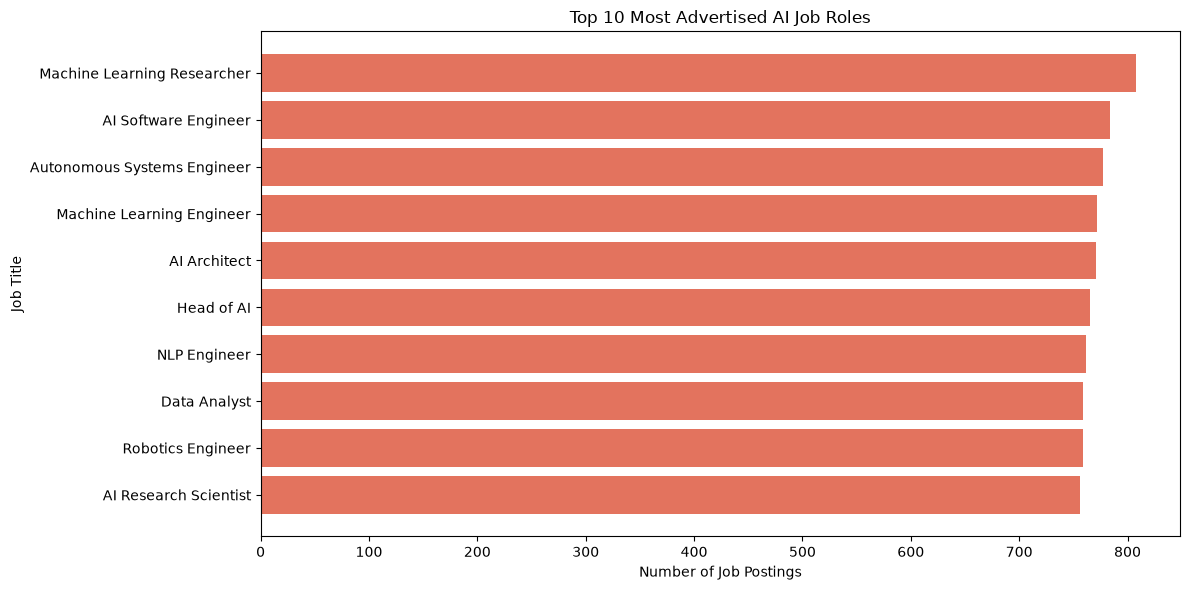

In [38]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_job_roles["job_title"][:10][::-1],
    top_job_roles["job_postings"][:10][::-1],
    color='#E3735E'
)

plt.title("Top 10 Most Advertised AI Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

##### Key Insights

- The dataset contains **20** unique AI job roles.
- **Machine Learning Researcher** is the most frequently advertised role with **808** job postings.
- The top 10 AI job roles received between **756 and 808** job postings each.
- Hiring demand is relatively balanced across different AI specializations, with no single role dominating the job market.

#### Question
**Which skills are most frequently required in AI job postings?**

In [39]:
top_skills = (
    df["required_skills"]
    .str.split(", ")
    .explode()
    .value_counts()
    .reset_index()
)

top_skills.columns = ["skill", "job_postings"]

top_skills.head(10)

,skill,job_postings
0,Python,4450
1,SQL,3407
2,TensorFlow,3022
3,Kubernetes,3009
4,Scala,2794
5,PyTorch,2777
6,Linux,2705
7,Git,2631
8,Java,2578
9,GCP,2442


Export Top Skills Table For Power BI

In [49]:
top_skills.to_csv("top_skills.csv", index=False)

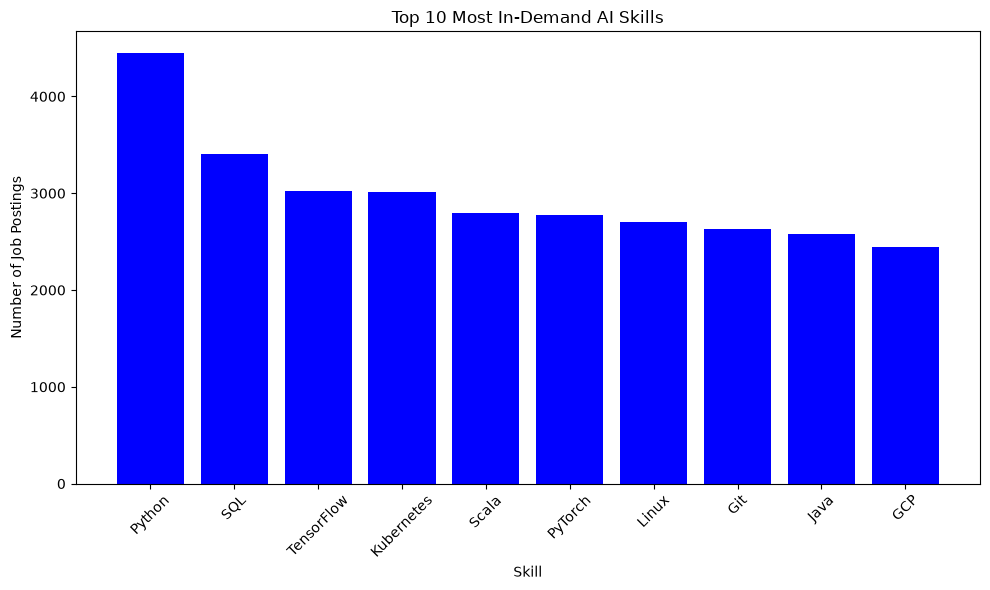

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_skills["skill"][:10],
    top_skills["job_postings"][:10],
    color="blue"
)

plt.title("Top 10 Most In-Demand AI Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Key Insights

- **Python** is the most frequently requested skill, appearing in **4,450** AI job postings.
- **SQL** ranks second with **3,407** job postings, highlighting the importance of data querying and database skills.
- **TensorFlow (3,022)** and **PyTorch (2,777)** are among the most in-demand machine learning frameworks.
- Cloud and infrastructure technologies such as **Kubernetes (3,009)** and **GCP (2,442)** are also widely required, reflecting the growing importance of deploying and managing AI applications.
- The demand spans programming languages, machine learning frameworks, cloud platforms, and DevOps tools, indicating that employers seek a diverse technical skill set rather than expertise in a single technology.

### Remote Work Adoption

#### Question
**How widely has remote work been adopted in AI job postings?**

In [41]:
remote_distribution = (
    df["remote_work_type"]
    .value_counts()
    .reset_index()
)

remote_distribution.columns = ["work_type", "job_postings"]

remote_distribution

,work_type,job_postings
0,On-site,5075
1,Hybrid,5005
2,Remote,4920


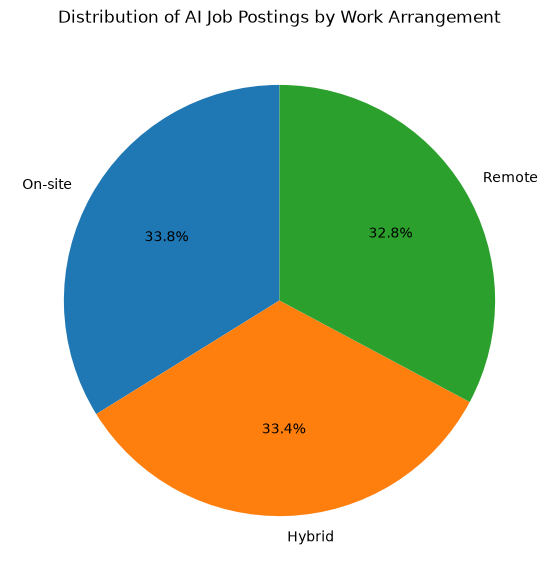

In [42]:
plt.figure(figsize=(7,7))

plt.pie(
    remote_distribution["job_postings"],
    labels=remote_distribution["work_type"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of AI Job Postings by Work Arrangement")

plt.show()

##### Key Insights

- **Remote** work accounts for **4,920 job postings** (32.8%), indicating that nearly one-third of AI jobs support fully remote work.
- **On-site** positions remain the most common with **5,075 job postings** (33.8%), followed closely by **Hybrid** positions with **5,005 job postings** (33.4%).
- The small differences among the three work arrangements suggest that AI employers have broadly adopted flexible work models, with remote, hybrid, and on-site jobs offered in nearly equal proportions.

### Career Planning

#### Question
**What insights can job seekers gain from the AI job market regarding salary, experience, education, and company size?**

In [43]:
# Average Salary by Experience Level
salary_experience = (
    df.groupby("experience_level")["salary_usd"]
    .mean().round(2)
    .reindex([
        "Entry Level",
        "Mid Level",
        "Senior Level",
        "Executive Level"
    ])
    .reset_index()
)
salary_experience

,experience_level,salary_usd
0,Entry Level,63133.38
1,Mid Level,87955.47
2,Senior Level,122187.66
3,Executive Level,187723.65


In [44]:
# Education Requirements
education = (
    df["education_required"]
    .value_counts()
    .reset_index()
)

education.columns = ["education", "job_postings"]
education

,education,job_postings
0,Bachelor,3789
1,Associate,3785
2,Master,3748
3,PhD,3678


In [45]:
# Company Size Distribution
company_size = (
    df["company_size"]
    .value_counts()
    .reset_index()
)

company_size.columns = ["company_size", "job_postings"]
company_size

,company_size,job_postings
0,Small,5007
1,Large,4998
2,Medium,4995


In [46]:
# Experience Level Distribution
experience_distribution = (
    df["experience_level"]
    .value_counts()
    .reindex([
        "Entry Level",
        "Mid Level",
        "Senior Level",
        "Executive Level"
    ])
    .reset_index()
)
experience_distribution


,experience_level,count
0,Entry Level,3718
1,Mid Level,3781
2,Senior Level,3741
3,Executive Level,3760


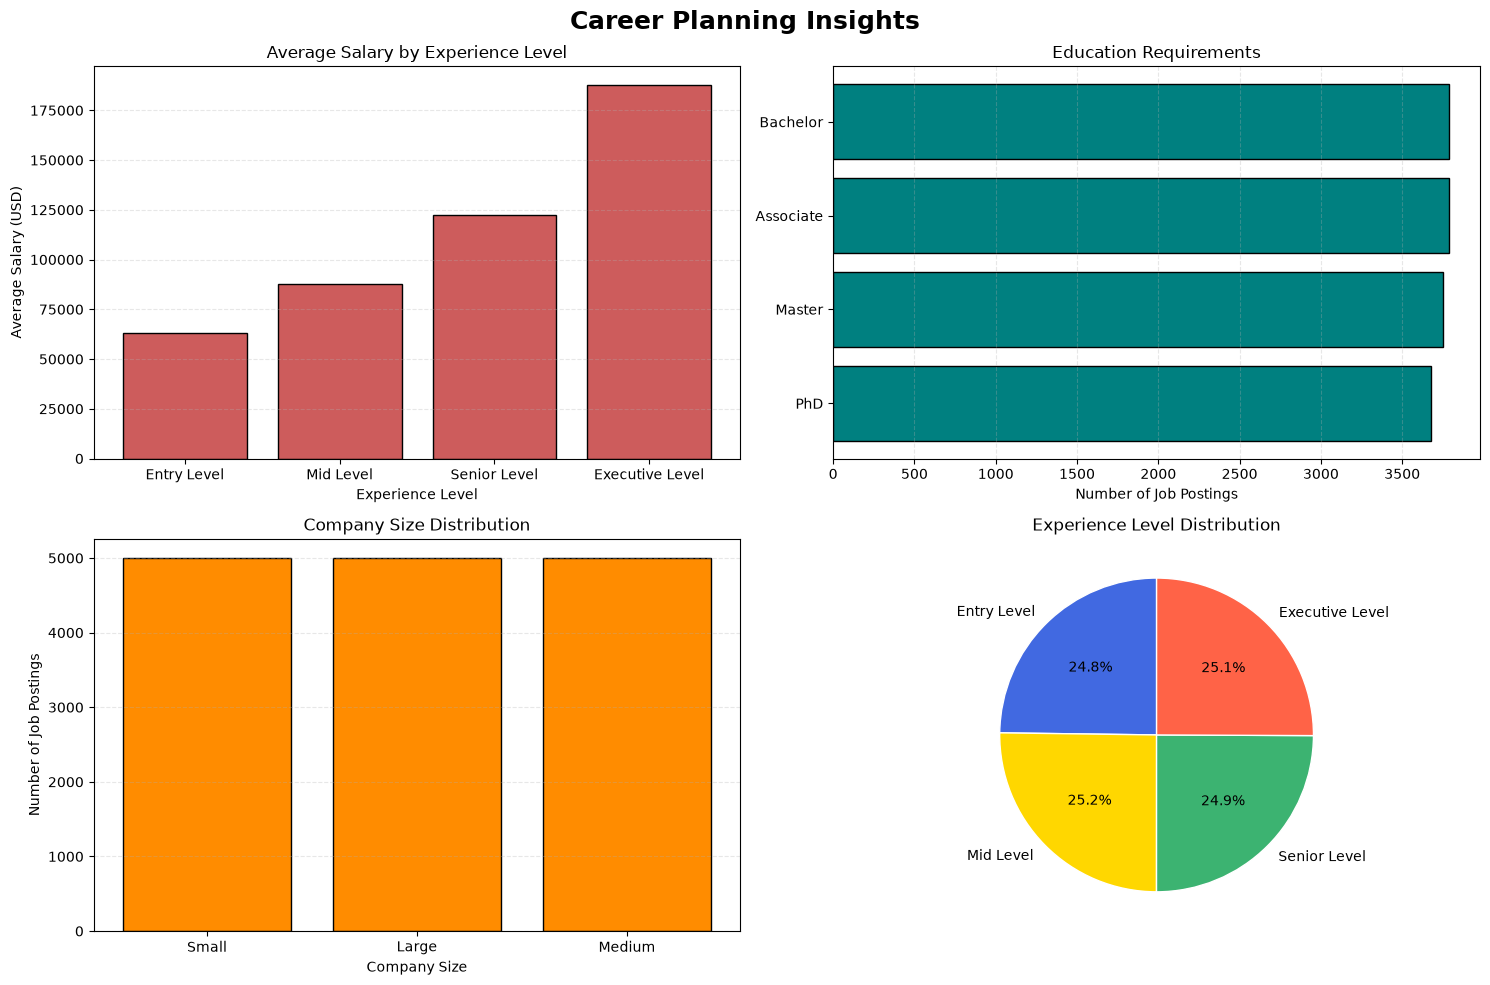

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Average Salary by Experience
axes[0, 0].bar(
    salary_experience["experience_level"],
    salary_experience["salary_usd"],
    color="indianred",
    edgecolor="black"
)

axes[0, 0].set_title("Average Salary by Experience Level")
axes[0, 0].set_xlabel("Experience Level")
axes[0, 0].set_ylabel("Average Salary (USD)")
axes[0, 0].grid(axis="y", linestyle="--", alpha=0.3)

# Education Requirements
axes[0, 1].barh(
    education["education"][::-1],
    education["job_postings"][::-1],
    color="teal",
    edgecolor="black"
)

axes[0, 1].set_title("Education Requirements")
axes[0, 1].set_xlabel("Number of Job Postings")
axes[0, 1].grid(axis="x", linestyle="--", alpha=0.3)

# Company Size Distribution
axes[1, 0].bar(
    company_size["company_size"],
    company_size["job_postings"],
    color="darkorange",
    edgecolor="black"
)

axes[1, 0].set_title("Company Size Distribution")
axes[1, 0].set_xlabel("Company Size")
axes[1, 0].set_ylabel("Number of Job Postings")
axes[1, 0].grid(axis="y", linestyle="--", alpha=0.3)

# Experience Level Distribution
axes[1, 1].pie(
    experience_distribution["count"],
    labels=experience_distribution["experience_level"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["royalblue", "gold", "mediumseagreen", "tomato"],
    wedgeprops=dict(edgecolor="white")
)

axes[1, 1].set_title("Experience Level Distribution")

fig.suptitle(
    "Career Planning Insights",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

##### Key Insights

- Average salaries increase consistently with experience, from **$63,133** for **Entry Level** roles to **$187,724** for **Executive Level** positions—nearly **3× higher** than entry-level salaries.
- **Bachelor's degrees (3,789 job postings)** are the most commonly requested educational qualification, although demand is relatively balanced across all education levels.
- AI job opportunities are almost evenly distributed across **Small (5,007)**, **Large (4,998)**, and **Medium (4,995)** companies, indicating that organizations of all sizes are actively hiring AI professionals.
- Demand for AI talent is also well balanced across experience levels, with each level accounting for approximately **3,700–3,800** job postings, suggesting opportunities for both entry-level and experienced professionals.

## Export Cleaned Dataset

In [48]:
# df.to_csv("ai_job_market_cleaned.csv", index=False)